
# Lab Sheet 4: Fourier Transform for Image Filtering

ISHIKA AWASTHI | ROLL NO. 23 | CU24250188


Image 1 shape: (335, 505)
Image 2 shape: (335, 505)


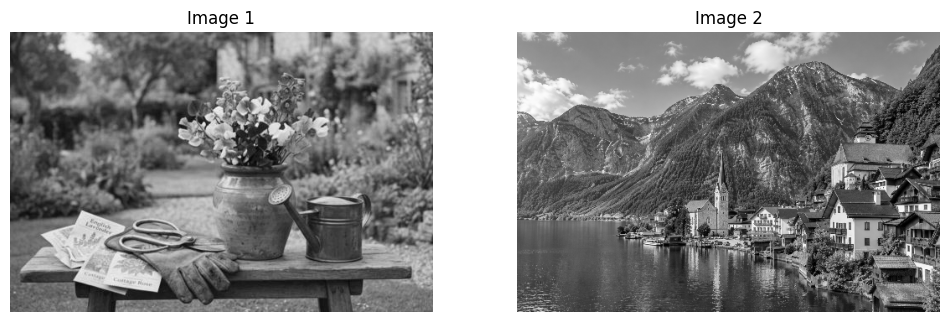

In [24]:
def synthetic_image(kind=1, size=(512, 512)):
    h, w = size
    y, x = np.mgrid[0:h, 0:w]
    # Create background as float32
    img_float = 35 + 20*np.sin(x/45) + 15*np.cos(y/55)

    # Add texture/patterns
    if kind == 1:
        img_float += 18*np.sin(x/5) * np.cos(y/7)
    else:
        img_float += 12*np.sin(x/8 + y/11)

    # Clip and cast to uint8 so OpenCV drawing functions work properly
    img = np.clip(img_float, 0, 255).astype(np.uint8)

    if kind == 1:
        # Shapes + edges + text
        cv2.rectangle(img, (55, 60), (230, 250), 185, -1)
        cv2.circle(img, (360, 170), 85, 220, -1)
        cv2.ellipse(img, (315, 360), (120, 65), 20, 0, 360, 160, -1)
        cv2.line(img, (30, 430), (480, 300), 245, 8)
        cv2.putText(img, "FOURIER", (115, 485), cv2.FONT_HERSHEY_SIMPLEX,
                    1.2, 230, 3, cv2.LINE_AA)
    else:
        cv2.circle(img, (150, 220), 100, 210, -1)
        cv2.rectangle(img, (275, 80), (465, 260), 150, -1)
        cv2.line(img, (40, 430), (470, 350), 240, 10)
        cv2.putText(img, "PHASE", (145, 485), cv2.FONT_HERSHEY_SIMPLEX,
                    1.3, 235, 3, cv2.LINE_AA)

    return img

def load_gray(path, fallback_kind=1):
    if path and os.path.exists(path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            return img
    if USE_SYNTHETIC_FALLBACK:
        return synthetic_image(fallback_kind)
    raise FileNotFoundError(
        f"Could not load {path}. Put the image in the notebook folder or enable fallback."
    )

img1 = load_gray(IMAGE_PATH_1, 1)
img2 = load_gray(IMAGE_PATH_2, 2)

# Keep images manageable and identical in size for frequency operations.
H, W = img1.shape
img2 = cv2.resize(img2, (W, H))

print("Image 1 shape:", img1.shape)
print("Image 2 shape:", img2.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img1, cmap="gray")
ax[0].set_title("Image 1")
ax[0].axis("off")
ax[1].imshow(img2, cmap="gray")
ax[1].set_title("Image 2")
ax[1].axis("off")
plt.show()

## Common Fourier Transform Utilities

In [25]:

# COMMON FOURIER UTILITIES

def fft2_shift(img):
    F = np.fft.fft2(img)
    return np.fft.fftshift(F)

def ifft2_shift(F_shifted):
    return np.real(np.fft.ifft2(np.fft.ifftshift(F_shifted)))

def magnitude_spectrum(F):
    return np.log1p(np.abs(F))

def phase_spectrum(F):
    return np.angle(F)

def normalize_uint8(img):
    img = np.asarray(img, dtype=np.float32)
    mn, mx = img.min(), img.max()
    if mx - mn < 1e-12:
        return np.zeros_like(img, dtype=np.uint8)
    return np.clip((img - mn) * 255.0 / (mx - mn), 0, 255).astype(np.uint8)

def distance_grid(shape):
    h, w = shape
    y, x = np.ogrid[:h, :w]
    cy, cx = h//2, w//2
    return np.sqrt((x-cx)**2 + (y-cy)**2)

F1 = fft2_shift(img1)

print("Fourier transform calculated.")


Fourier transform calculated.



## 1. 2D Fourier Spectrum: Magnitude and Phase


ISHIKA AWASTHI | ROLL NO. 23 | CU24250188


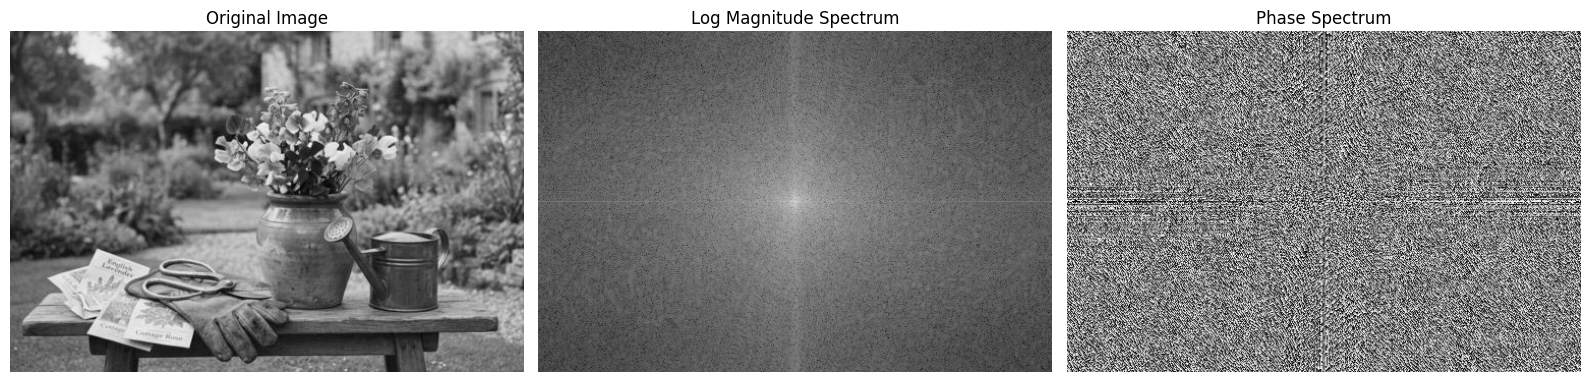

Magnitude range: 4.461080885551653 to 19435574.0
Phase range: -3.142 to 3.142 radians


In [26]:

# TASK 1: 2D FOURIER MAGNITUDE + PHASE

F = fft2_shift(img1)
mag = magnitude_spectrum(F)
phase = phase_spectrum(F)

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(img1, cmap="gray")
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(mag, cmap="gray")
ax[1].set_title("Log Magnitude Spectrum")
ax[1].axis("off")

ax[2].imshow(phase, cmap="gray")
ax[2].set_title("Phase Spectrum")
ax[2].axis("off")

plt.tight_layout()
plt.show()

print("Magnitude range:", float(np.abs(F).min()), "to", float(np.abs(F).max()))
print("Phase range: {:.3f} to {:.3f} radians".format(phase.min(), phase.max()))



## 2. Frequency-Domain Low-Pass Filters



ISHIKA AWASTHI | ROLL NO. 23 | CU24250188


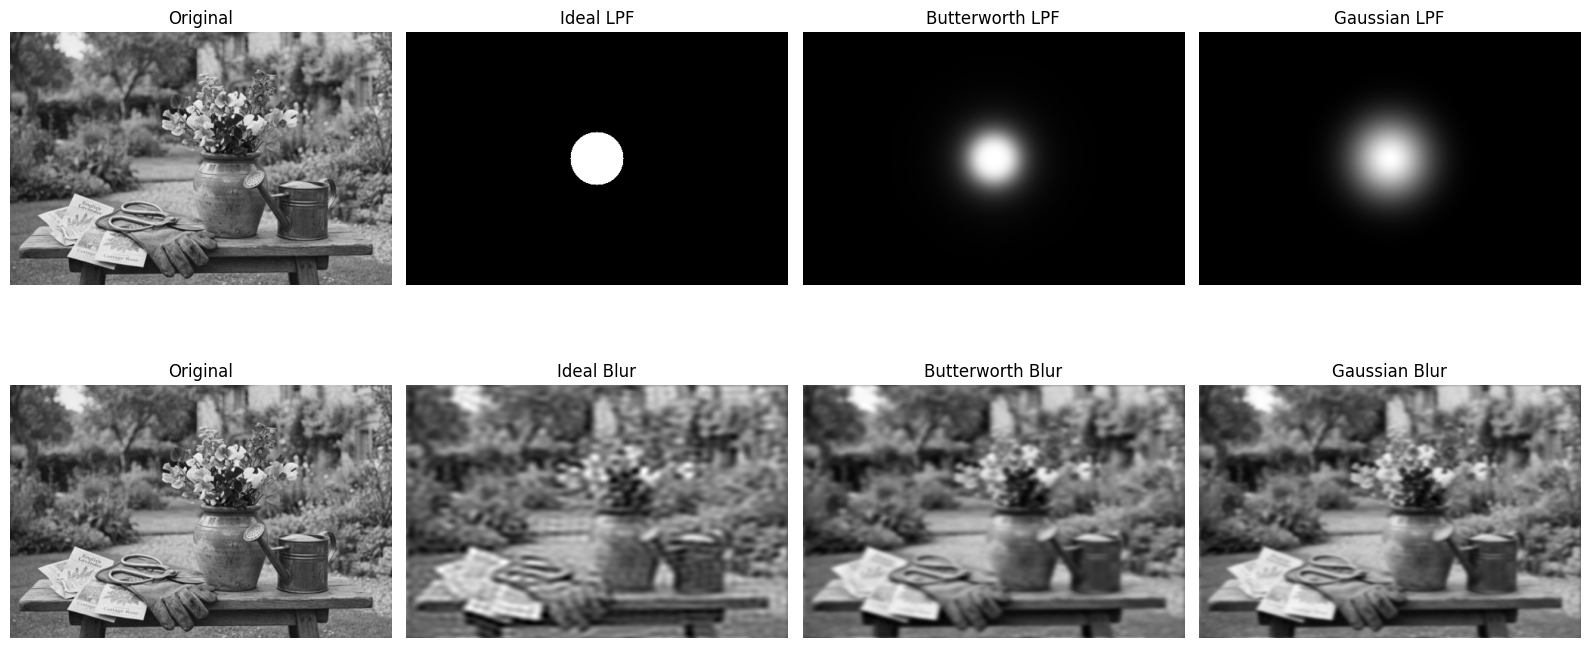

In [27]:

# TASK 2: IDEAL, BUTTERWORTH AND GAUSSIAN LOW-PASS FILTERS

def ideal_lowpass(shape, D0):
    D = distance_grid(shape)
    return (D <= D0).astype(np.float32)

def butterworth_lowpass(shape, D0, order=2):
    D = distance_grid(shape)
    return 1.0 / (1.0 + (D / max(D0, 1e-8))**(2*order))

def gaussian_lowpass(shape, D0):
    D = distance_grid(shape)
    return np.exp(-(D**2) / (2*(D0**2)))

def apply_frequency_filter(img, H_filter):
    F = fft2_shift(img)
    G = F * H_filter
    return normalize_uint8(ifft2_shift(G))

D0 = 35

H_ideal = ideal_lowpass(img1.shape, D0)
H_butter = butterworth_lowpass(img1.shape, D0, order=2)
H_gaussian = gaussian_lowpass(img1.shape, D0)

lp_ideal = apply_frequency_filter(img1, H_ideal)
lp_butter = apply_frequency_filter(img1, H_butter)
lp_gaussian = apply_frequency_filter(img1, H_gaussian)

fig, ax = plt.subplots(2, 4, figsize=(16, 8))
ax[0,0].imshow(img1, cmap="gray"); ax[0,0].set_title("Original")
ax[0,1].imshow(H_ideal, cmap="gray"); ax[0,1].set_title("Ideal LPF")
ax[0,2].imshow(H_butter, cmap="gray"); ax[0,2].set_title("Butterworth LPF")
ax[0,3].imshow(H_gaussian, cmap="gray"); ax[0,3].set_title("Gaussian LPF")

ax[1,0].imshow(img1, cmap="gray"); ax[1,0].set_title("Original")
ax[1,1].imshow(lp_ideal, cmap="gray"); ax[1,1].set_title("Ideal Blur")
ax[1,2].imshow(lp_butter, cmap="gray"); ax[1,2].set_title("Butterworth Blur")
ax[1,3].imshow(lp_gaussian, cmap="gray"); ax[1,3].set_title("Gaussian Blur")

for a in ax.ravel():
    a.axis("off")
plt.tight_layout()
plt.show()



## 3. Frequency-Domain High-Pass Filtering and Edge Detection


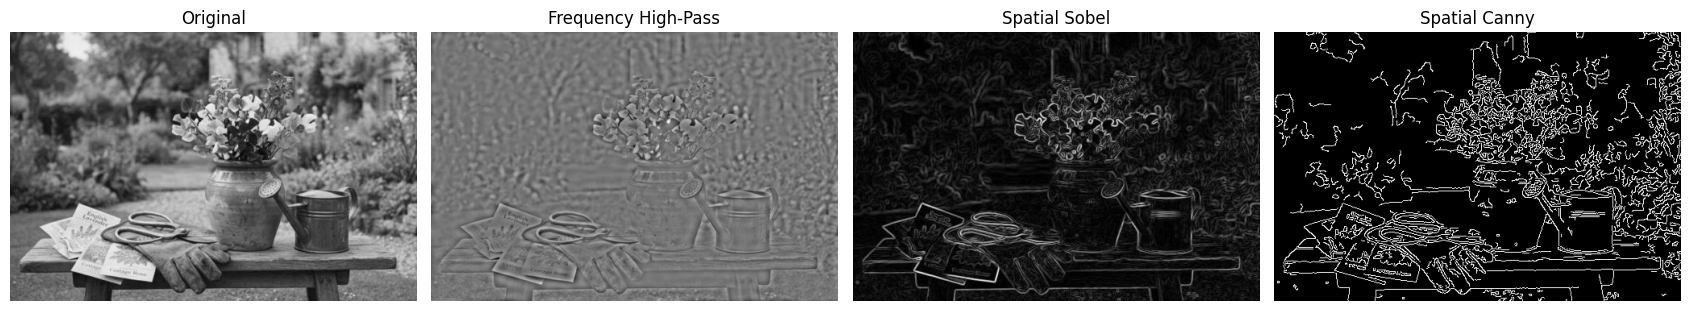

In [28]:

# TASK 3: HIGH-PASS FILTER + SPATIAL EDGE DETECTION

def ideal_highpass(shape, D0):
    return 1.0 - ideal_lowpass(shape, D0)

D0_hp = 25
H_hp = ideal_highpass(img1.shape, D0_hp)
hp_result = apply_frequency_filter(img1, H_hp)

# Spatial-domain edge detection for comparison
sobel_x = cv2.Sobel(img1, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img1, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.magnitude(sobel_x.astype(np.float32), sobel_y.astype(np.float32))
sobel_result = normalize_uint8(sobel_mag)

canny_result = cv2.Canny(img1, 100, 200)

fig, ax = plt.subplots(1, 4, figsize=(17, 5))
ax[0].imshow(img1, cmap="gray"); ax[0].set_title("Original")
ax[1].imshow(hp_result, cmap="gray"); ax[1].set_title("Frequency High-Pass")
ax[2].imshow(sobel_result, cmap="gray"); ax[2].set_title("Spatial Sobel")
ax[3].imshow(canny_result, cmap="gray"); ax[3].set_title("Spatial Canny")

for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()



## 4. Periodic-Noise Removal Using a Notch Filter


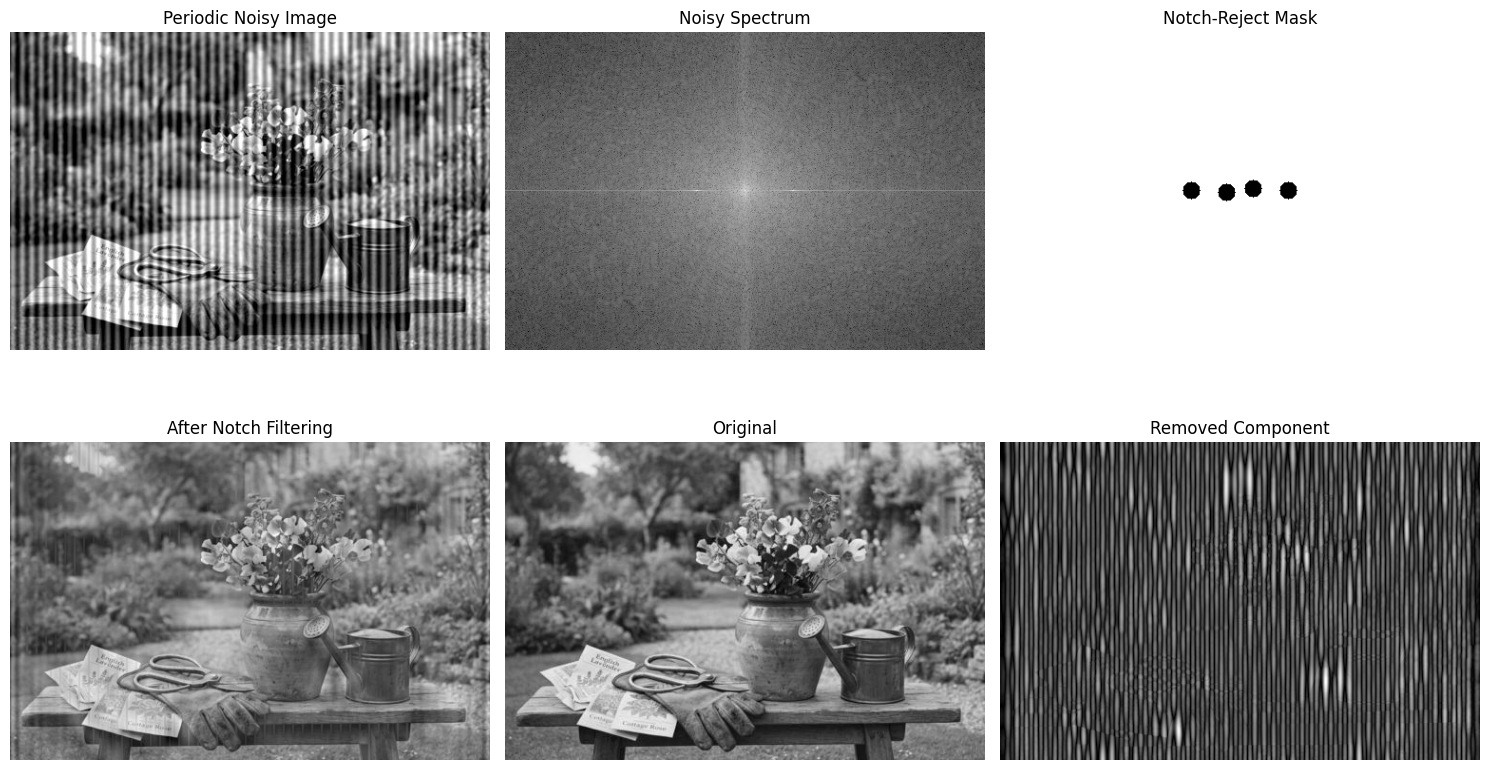

Detected spectral peak coordinates: [(np.int64(167), np.int64(201)), (np.int64(167), np.int64(303)), (np.int64(165), np.int64(266)), (np.int64(169), np.int64(238))]


In [29]:

# TASK 4: PERIODIC NOISE + AUTOMATIC NOTCH REJECTION

def add_periodic_noise(img, amplitude=45, fx=0.08, fy=0.0):
    h, w = img.shape
    y, x = np.mgrid[0:h, 0:w]
    noise = amplitude * np.sin(2*np.pi*(fx*x + fy*y))
    noisy = np.clip(img.astype(np.float32) + noise, 0, 255)
    return noisy.astype(np.uint8)

def find_spectral_peaks(F, count=4, exclusion_radius=12):
    mag = np.abs(F).copy()
    h, w = mag.shape
    cy, cx = h//2, w//2

    yy, xx = np.ogrid[:h, :w]
    center_mask = (xx-cx)**2 + (yy-cy)**2 <= exclusion_radius**2
    mag[center_mask] = 0

    coords = []
    for _ in range(count):
        idx = np.argmax(mag)
        py, px = np.unravel_index(idx, mag.shape)
        coords.append((py, px))
        y1, y2 = max(0, py-exclusion_radius), min(h, py+exclusion_radius+1)
        x1, x2 = max(0, px-exclusion_radius), min(w, px+exclusion_radius+1)
        mag[y1:y2, x1:x2] = 0
    return coords

def notch_reject(shape, centers, radius=7):
    h, w = shape
    yy, xx = np.ogrid[:h, :w]
    Hn = np.ones((h, w), dtype=np.float32)
    for cy, cx in centers:
        mask = (yy-cy)**2 + (xx-cx)**2 <= radius**2
        Hn[mask] = 0
    return Hn

noisy = add_periodic_noise(img1, amplitude=55, fx=0.10)
Fn = fft2_shift(noisy)
peaks = find_spectral_peaks(Fn, count=4, exclusion_radius=14)

H_notch = notch_reject(noisy.shape, peaks, radius=9)
cleaned = normalize_uint8(ifft2_shift(Fn * H_notch))

fig, ax = plt.subplots(2, 3, figsize=(15, 9))
ax[0,0].imshow(noisy, cmap="gray"); ax[0,0].set_title("Periodic Noisy Image")
ax[0,1].imshow(np.log1p(np.abs(Fn)), cmap="gray"); ax[0,1].set_title("Noisy Spectrum")
ax[0,2].imshow(H_notch, cmap="gray"); ax[0,2].set_title("Notch-Reject Mask")
ax[1,0].imshow(cleaned, cmap="gray"); ax[1,0].set_title("After Notch Filtering")
ax[1,1].imshow(img1, cmap="gray"); ax[1,1].set_title("Original")
ax[1,2].imshow(np.abs(noisy.astype(float)-cleaned.astype(float)), cmap="gray")
ax[1,2].set_title("Removed Component")

for a in ax.ravel():
    a.axis("off")
plt.tight_layout()
plt.show()

print("Detected spectral peak coordinates:", peaks)



## 5. Fourier Image Compression Using Top-k Coefficients


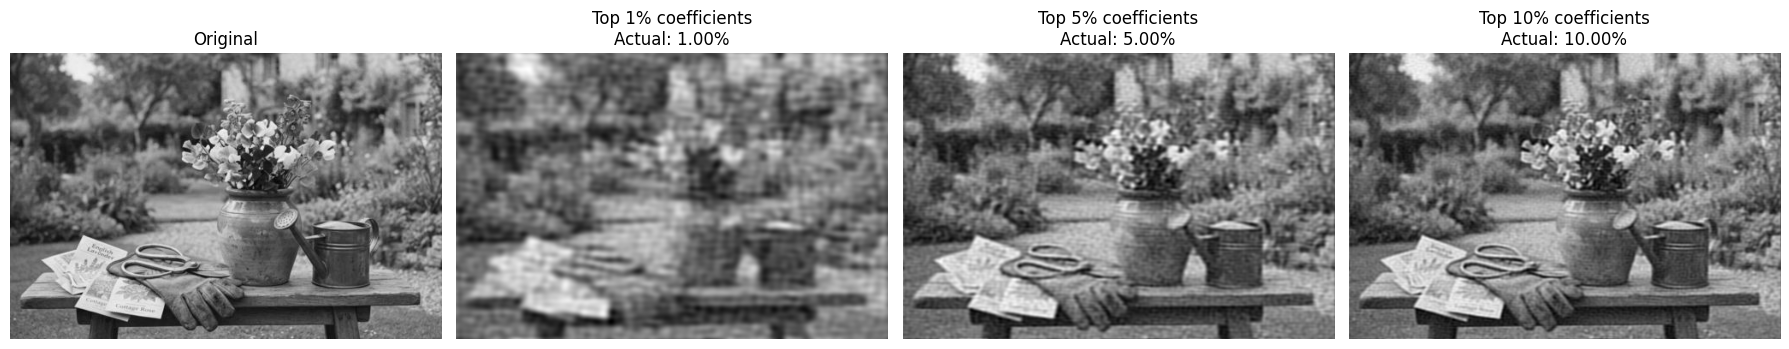

In [30]:

# TASK 5: TOP-K FOURIER COEFFICIENT COMPRESSION

def top_k_fourier_reconstruction(img, keep_percent=5):
    F = fft2_shift(img)
    flat = np.abs(F).ravel()
    k = max(1, int(len(flat) * keep_percent / 100.0))

    threshold = np.partition(flat, -k)[-k]
    mask = np.abs(F) >= threshold
    F_keep = F * mask

    reconstructed = normalize_uint8(ifft2_shift(F_keep))
    actual_percent = 100 * np.count_nonzero(mask) / mask.size
    return reconstructed, mask, actual_percent

percentages = [1, 5, 10]
fig, ax = plt.subplots(1, len(percentages)+1, figsize=(18, 5))
ax[0].imshow(img1, cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

for i, p in enumerate(percentages, start=1):
    rec, mask, actual = top_k_fourier_reconstruction(img1, p)
    ax[i].imshow(rec, cmap="gray")
    ax[i].set_title(f"Top {p}% coefficients\nActual: {actual:.2f}%")
    ax[i].axis("off")

plt.tight_layout()
plt.show()



## 6. Frequency-Domain Watermark Hide / Reveal



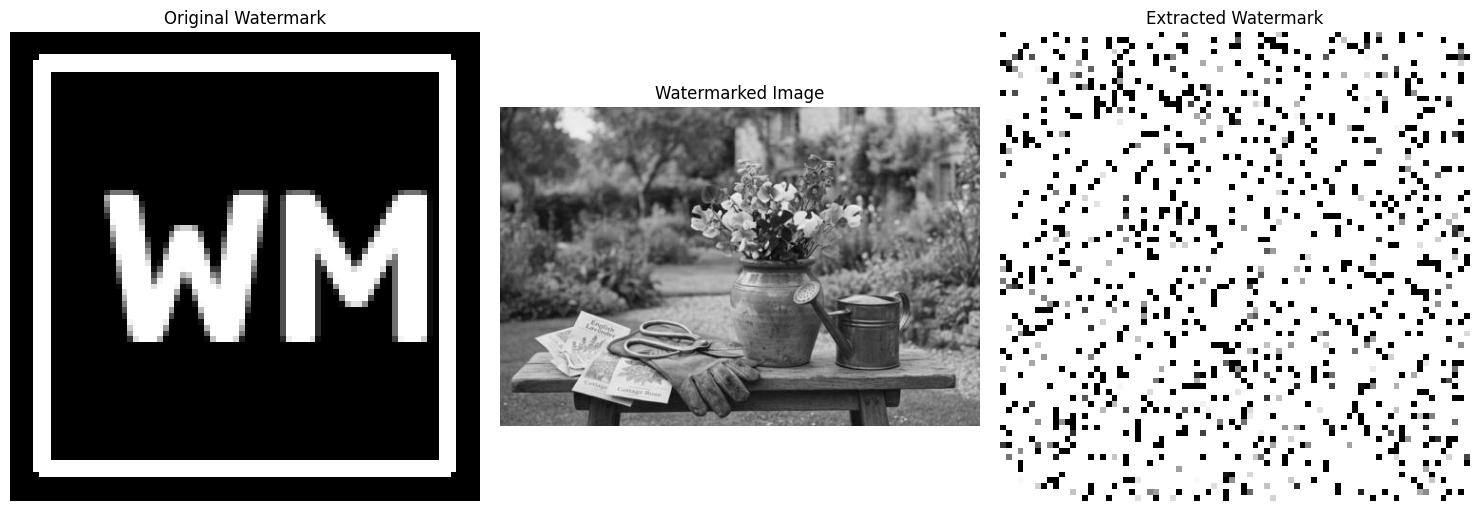

In [31]:

# TASK 6: FREQUENCY-DOMAIN WATERMARK EMBEDDING + EXTRACTION

def make_watermark(size=(80, 80)):
    wm = np.zeros(size, dtype=np.uint8)
    cv2.rectangle(wm, (5, 5), (size[1]-6, size[0]-6), 255, 2)
    cv2.putText(wm, "WM", (15, 53), cv2.FONT_HERSHEY_SIMPLEX,
                1.25, 255, 2, cv2.LINE_AA)
    return wm

def embed_watermark(img, watermark, strength=18, seed=123):
    F = fft2_shift(img).astype(np.complex128)
    h, w = img.shape
    wh, ww = watermark.shape

    rng = np.random.default_rng(seed)
    candidates = []
    cy, cx = h//2, w//2

    # High-frequency annulus, avoiding the very outer edge.
    for y in range(h):
        for x in range(w):
            r = np.sqrt((y-cy)**2 + (x-cx)**2)
            if min(h,w)*0.22 < r < min(h,w)*0.38:
                candidates.append((y,x))

    rng.shuffle(candidates)
    n = wh * ww
    selected = candidates[:n]

    # Store the watermark in coefficient magnitudes.
    wm_flat = watermark.ravel() / 255.0
    for (y,x), bit in zip(selected, wm_flat):
        current = np.abs(F[y,x])
        F[y,x] = (current + strength*bit) * np.exp(1j*np.angle(F[y,x]))

    # Preserve conjugate symmetry approximately by mirroring coefficients.
    for (y,x) in selected:
        yy, xx = (2*cy-y) % h, (2*cx-x) % w
        F[yy,xx] = np.conj(F[y,x])

    watermarked = normalize_uint8(ifft2_shift(F))
    return watermarked, F, selected

def extract_watermark(original_img, watermarked_img, watermark_shape, strength=18, seed=123):
    F0 = fft2_shift(original_img).astype(np.complex128)
    Fw = fft2_shift(watermarked_img).astype(np.complex128)
    h, w = original_img.shape
    wh, ww = watermark_shape

    rng = np.random.default_rng(seed)
    candidates = []
    cy, cx = h//2, w//2
    for y in range(h):
        for x in range(w):
            r = np.sqrt((y-cy)**2 + (x-cx)**2)
            if min(h,w)*0.22 < r < min(h,w)*0.38:
                candidates.append((y,x))
    rng.shuffle(candidates)
    selected = candidates[:wh*ww]

    values = []
    for y,x in selected:
        delta = (np.abs(Fw[y,x]) - np.abs(F0[y,x])) / max(strength, 1e-8)
        values.append(delta)

    wm = np.clip(np.array(values).reshape(wh,ww), 0, 1) * 255
    return wm.astype(np.uint8)

watermark = make_watermark()
watermarked, Fw, selected = embed_watermark(img1, watermark, strength=20)
extracted = extract_watermark(img1, watermarked, watermark.shape, strength=20)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(watermark, cmap="gray"); ax[0].set_title("Original Watermark")
ax[1].imshow(watermarked, cmap="gray"); ax[1].set_title("Watermarked Image")
ax[2].imshow(extracted, cmap="gray"); ax[2].set_title("Extracted Watermark")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()



## 7. Band-Pass and Band-Reject Filters




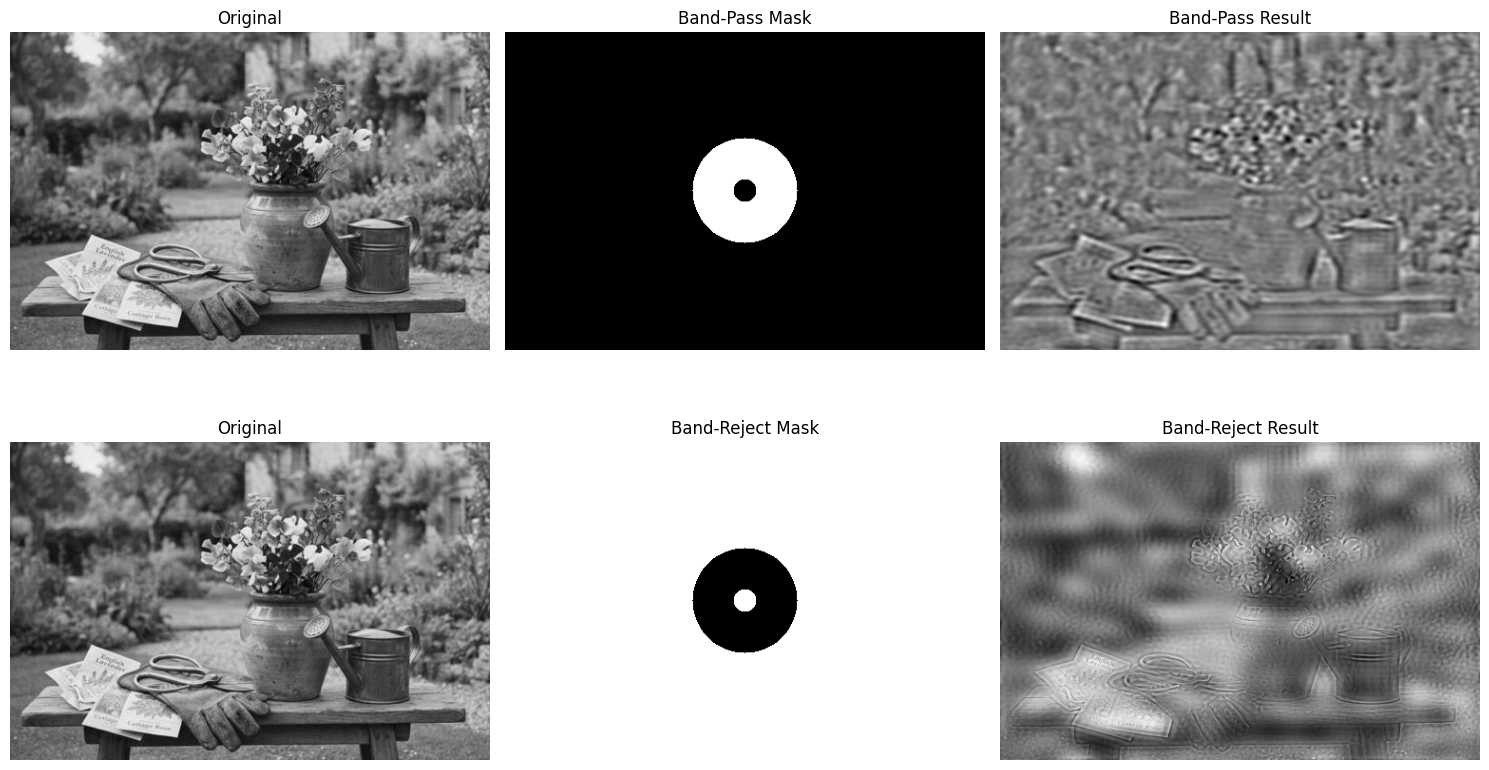

In [32]:

# TASK 7: BAND-PASS + BAND-REJECT FILTER DESIGNER

def ideal_bandpass(shape, D_low, D_high):
    D = distance_grid(shape)
    return ((D >= D_low) & (D <= D_high)).astype(np.float32)

def ideal_bandreject(shape, D_low, D_high):
    return 1.0 - ideal_bandpass(shape, D_low, D_high)

D_low, D_high = 12, 55
H_bp = ideal_bandpass(img1.shape, D_low, D_high)
H_br = ideal_bandreject(img1.shape, D_low, D_high)

bandpass = apply_frequency_filter(img1, H_bp)
bandreject = apply_frequency_filter(img1, H_br)

fig, ax = plt.subplots(2, 3, figsize=(15, 9))
ax[0,0].imshow(img1, cmap="gray"); ax[0,0].set_title("Original")
ax[0,1].imshow(H_bp, cmap="gray"); ax[0,1].set_title("Band-Pass Mask")
ax[0,2].imshow(bandpass, cmap="gray"); ax[0,2].set_title("Band-Pass Result")

ax[1,0].imshow(img1, cmap="gray"); ax[1,0].set_title("Original")
ax[1,1].imshow(H_br, cmap="gray"); ax[1,1].set_title("Band-Reject Mask")
ax[1,2].imshow(bandreject, cmap="gray"); ax[1,2].set_title("Band-Reject Result")

for a in ax.ravel():
    a.axis("off")
plt.tight_layout()
plt.show()



## 8. Swap Phase and Magnitude Between Two Images


ISHIKA AWASTHI | ROLL NO. 23 | CU24250188


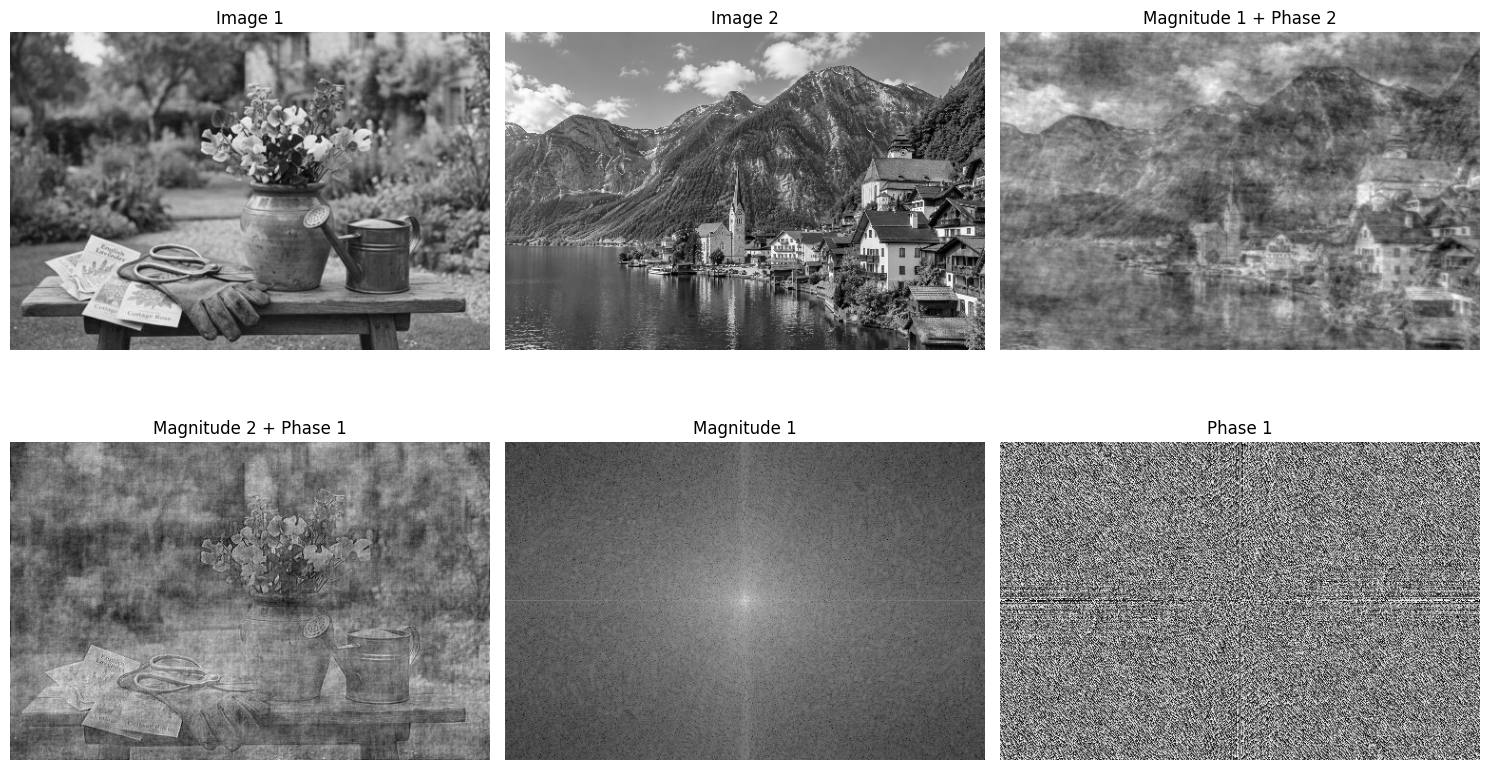

In [33]:

# TASK 8: PHASE / MAGNITUDE SWAP

F_a = fft2_shift(img1)
F_b = fft2_shift(img2)

mag_a, phase_a = np.abs(F_a), np.angle(F_a)
mag_b, phase_b = np.abs(F_b), np.angle(F_b)

swap_mag_a_phase_b = np.real(
    np.fft.ifft2(np.fft.ifftshift(mag_a * np.exp(1j*phase_b)))
)
swap_mag_b_phase_a = np.real(
    np.fft.ifft2(np.fft.ifftshift(mag_b * np.exp(1j*phase_a)))
)

swap_mag_a_phase_b = normalize_uint8(swap_mag_a_phase_b)
swap_mag_b_phase_a = normalize_uint8(swap_mag_b_phase_a)

fig, ax = plt.subplots(2, 3, figsize=(15, 9))
ax[0,0].imshow(img1, cmap="gray"); ax[0,0].set_title("Image 1")
ax[0,1].imshow(img2, cmap="gray"); ax[0,1].set_title("Image 2")
ax[0,2].imshow(swap_mag_a_phase_b, cmap="gray")
ax[0,2].set_title("Magnitude 1 + Phase 2")

ax[1,0].imshow(swap_mag_b_phase_a, cmap="gray")
ax[1,0].set_title("Magnitude 2 + Phase 1")
ax[1,1].imshow(np.log1p(mag_a), cmap="gray"); ax[1,1].set_title("Magnitude 1")
ax[1,2].imshow(phase_a, cmap="gray"); ax[1,2].set_title("Phase 1")

for a in ax.ravel():
    a.axis("off")
plt.tight_layout()
plt.show()



## 9. Blur Detection from High-Frequency Energy


ISHIKA AWASTHI | ROLL NO. 23 | CU24250188


,Image,High-frequency energy,Decision
0,Sharp,0.014243,BLURRY
1,Blurred,0.000448,BLURRY


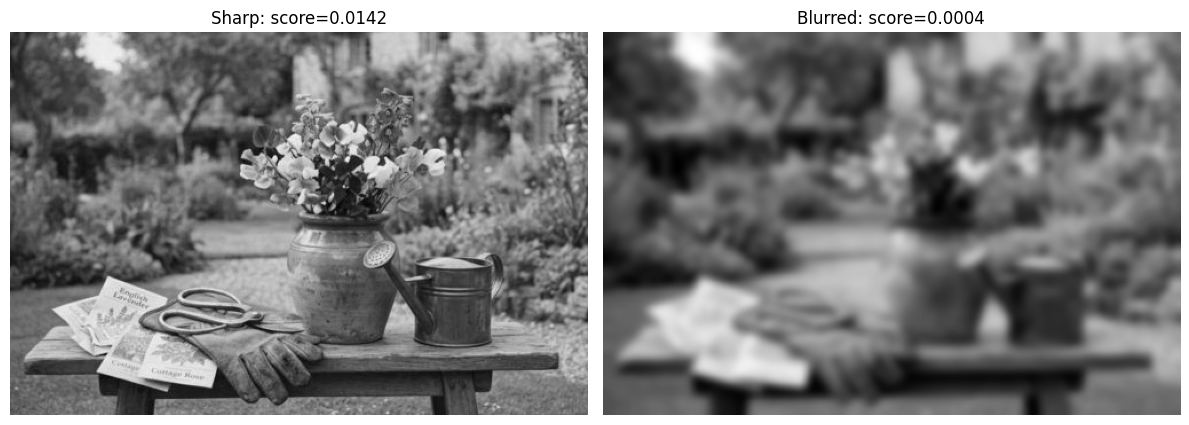

Blur threshold used in this demo: 0.08
For a real dataset, calibrate the threshold using labelled sharp/blurred samples.


In [34]:

# TASK 9: BLUR DETECTION

def high_frequency_energy_score(img, cutoff_ratio=0.12):
    F = fft2_shift(img)
    power = np.abs(F)**2
    D = distance_grid(img.shape)
    cutoff = cutoff_ratio * min(img.shape)
    high = power[D > cutoff].sum()
    total = power.sum()
    return float(high / max(total, 1e-12))

def blur_detector(img, threshold=0.08):
    score = high_frequency_energy_score(img)
    label = "SHARP" if score >= threshold else "BLURRY"
    return score, label

# Create controlled examples
sharp = img1.copy()
blur_sigma = 4
blurred = cv2.GaussianBlur(sharp, (0,0), blur_sigma)

score_sharp, label_sharp = blur_detector(sharp)
score_blur, label_blur = blur_detector(blurred)

results = pd.DataFrame({
    "Image": ["Sharp", "Blurred"],
    "High-frequency energy": [score_sharp, score_blur],
    "Decision": [label_sharp, label_blur]
})

display(results)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(sharp, cmap="gray"); ax[0].set_title(f"Sharp: score={score_sharp:.4f}")
ax[1].imshow(blurred, cmap="gray"); ax[1].set_title(f"Blurred: score={score_blur:.4f}")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

# Optional: test your own image with the detector
print("Blur threshold used in this demo:", 0.08)
print("For a real dataset, calibrate the threshold using labelled sharp/blurred samples.")



## 10. Spatial-Domain vs Frequency-Domain Filtering


ISHIKA AWASTHI | ROLL NO. 23 | CU24250188


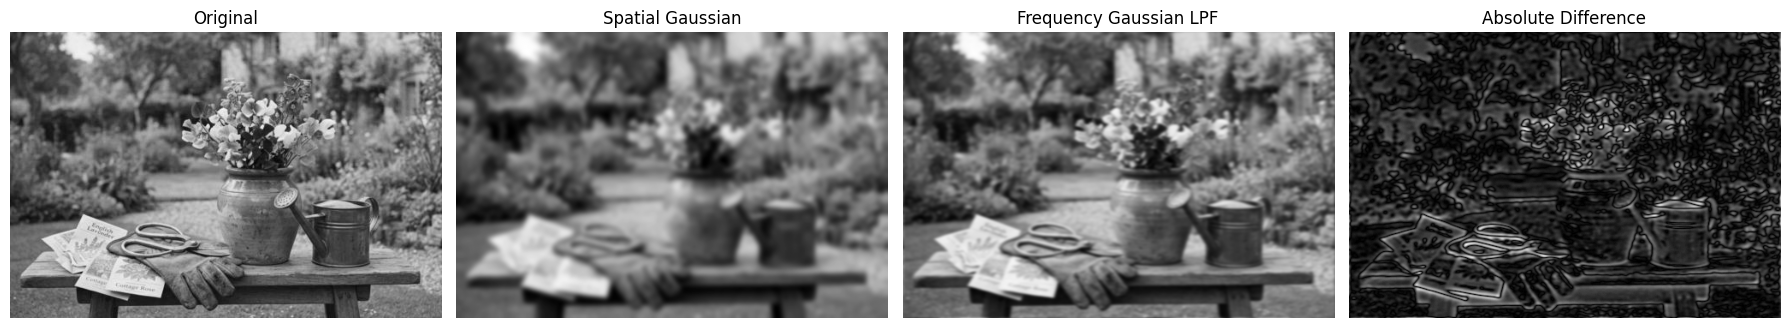

Mean absolute difference: 11.295829762080686


In [35]:

# TASK 10: SIDE-BY-SIDE SPATIAL VS FREQUENCY-DOMAIN FILTERING

# Spatial-domain Gaussian filtering
spatial_blur = cv2.GaussianBlur(img1, (0,0), sigmaX=3)

# Frequency-domain Gaussian low-pass
# Choose D0 approximately to produce comparable smoothing.
freq_gaussian_mask = gaussian_lowpass(img1.shape, D0=45)
frequency_blur = apply_frequency_filter(img1, freq_gaussian_mask)

# Absolute difference
difference = cv2.absdiff(spatial_blur, frequency_blur)

fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(img1, cmap="gray")
ax[0].set_title("Original")
ax[1].imshow(spatial_blur, cmap="gray")
ax[1].set_title("Spatial Gaussian")
ax[2].imshow(frequency_blur, cmap="gray")
ax[2].set_title("Frequency Gaussian LPF")
ax[3].imshow(difference, cmap="gray")
ax[3].set_title("Absolute Difference")

for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

print("Mean absolute difference:",
      float(np.mean(np.abs(spatial_blur.astype(float) - frequency_blur.astype(float)))))
